In [1]:
# Cell 1
# 对于华大 BGI Stereo-seq 数据，第一步先做环境自检，确保解释器和 stereopy 版本正确。
# 原因：不同环境/版本会导致 API 行为差异，先确认环境可避免后续读数或可视化报错。

import stereo as st
import matplotlib.pyplot as plt
import os
import sys
from natsort import natsorted
import stereo as st
from stereo.core.ms_data import MSData
from stereo.core.ms_pipeline import slice_generator
import warnings

warnings.filterwarnings('ignore')

print("stereopy version:", st.__version__)
print("Python executable:", sys.executable)

if "stereopy" in sys.executable:
    print("✅ 当前解释器路径包含 'stereopy'，看起来在目标 Conda 环境中。")
else:
    print("⚠️ 当前解释器路径不包含 'stereopy'，请确认你已激活: conda activate stereopy")

stereopy version: 1.6.2
Python executable: /home/lij/miniforge/envs/stereopy/bin/python
✅ 当前解释器路径包含 'stereopy'，看起来在目标 Conda 环境中。


In [2]:
print(os.getcwd())

/mnt/jupiter/lij/spatial


In [3]:
# Cell 2
# 对于华大 BGI 芯片空转数据，先按 Bin（这里 bin_size=50）读取是常见起点。
# 原因：bin 聚合能在空间分辨率与信号稳定性之间取得平衡，便于后续 QC 与聚类。

gef_path = "/home/lij/projects/spatial/data/LC_4B.raw.gef"
bin_size = 50

data = st.io.read_gef(
    file_path=gef_path,
    bin_type="bins",
    bin_size=bin_size,
)

print("读取完成")
print("n_bins:", data.n_cells)
print("n_genes:", data.n_genes)

[2026-03-15 15:11:53][Stereo][3304742][MainThread][123139629504320][reader][1357][INFO]: read_gef begin ...


2026-03-15 15:11:53 [INFO   ] input file:/home/lij/projects/spatial/data/LC_4B.raw.gef specify block size:50
2026-03-15 15:11:59 [INFO   ] generateBinInfo elspaed 64.112614 cpu sec


[2026-03-15 15:12:28][Stereo][3304742][MainThread][123139629504320][reader][1530][INFO]: the matrix has 51658 cells, and 49350 genes.
[2026-03-15 15:12:28][Stereo][3304742][MainThread][123139629504320][reader][1531][INFO]: read_gef end.


读取完成
n_bins: 51658
n_genes: 49350


⚠️ 未识别到 MT-/mt- 线粒体基因，mito_pct 已置为 0。
            n_genes  total_counts  mito_pct
count  51658.000000  51658.000000   51658.0
mean    1257.280208   2236.978745       0.0
std      838.195805   1577.815877       0.0
min        1.000000      1.000000       0.0
25%      402.000000    516.000000       0.0
50%     1472.000000   2561.000000       0.0
75%     1934.000000   3515.000000       0.0
max     3373.000000   7300.000000       0.0


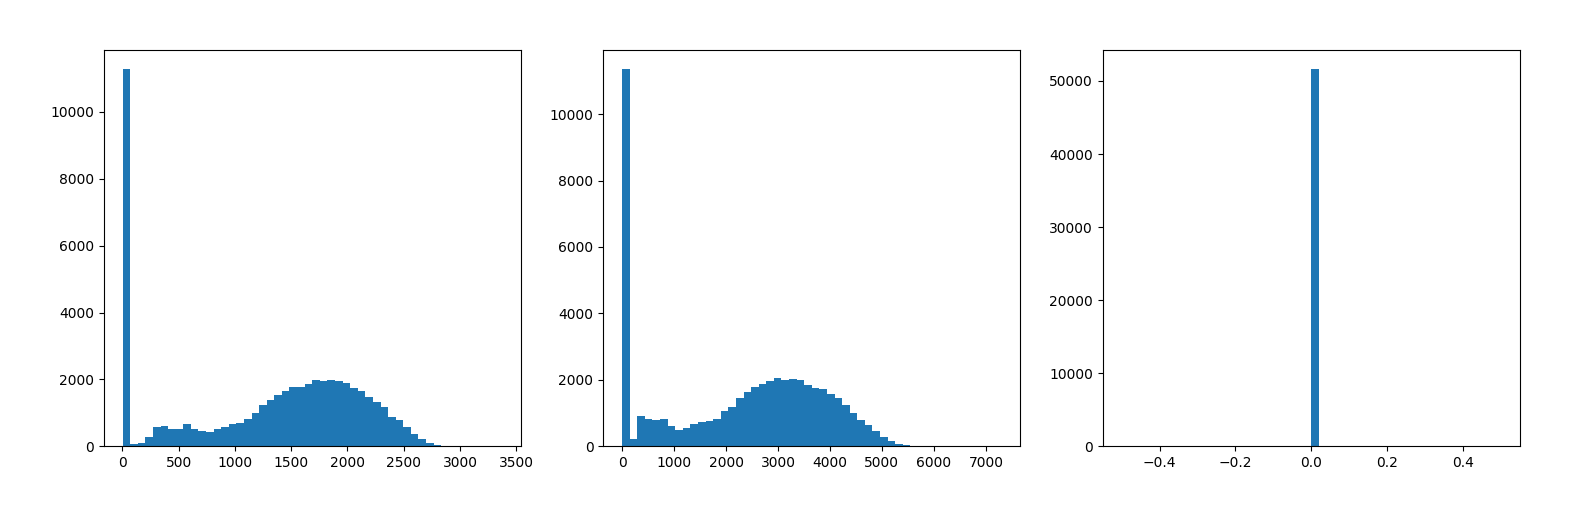

In [5]:
# Cell 3
# QC 先看 n_genes、total_counts、线粒体比例 mito_pct。
# 原因：
# 1) n_genes 太低常提示该 Bin 信号弱或背景噪声高；
# 2) total_counts 反映该 Bin 捕获分子量（表达总量）；
# 3) 线粒体比例异常升高常提示局部质量问题，需在过滤时重点关注。

import numpy as np
import pandas as pd
from scipy import sparse

exp = data.exp_matrix
if not sparse.issparse(exp):
    exp = sparse.csr_matrix(exp)
else:
    exp = exp.tocsr()

n_genes = np.array((exp > 0).sum(axis=1)).reshape(-1)
total_counts = np.array(exp.sum(axis=1)).reshape(-1)

if hasattr(data.genes, "gene_name"):
    gene_names = np.array(data.genes.gene_name).astype(str)
elif hasattr(data.genes, "index"):
    gene_names = np.array(data.genes.index).astype(str)
else:
    gene_names = np.array(data.genes).astype(str)

mito_mask = np.char.startswith(gene_names, "MT-") | np.char.startswith(gene_names, "mt-")
if mito_mask.sum() > 0:
    mito_counts = np.array(exp[:, mito_mask].sum(axis=1)).reshape(-1)
    mito_pct = np.where(total_counts > 0, mito_counts / total_counts * 100, 0.0)
else:
    mito_pct = np.zeros_like(total_counts)
    print("⚠️ 未识别到 MT-/mt- 线粒体基因，mito_pct 已置为 0。")

qc_df = pd.DataFrame({
    "n_genes": n_genes,
    "total_counts": total_counts,
    "mito_pct": mito_pct,
})

print(qc_df.describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(qc_df["n_genes"], bins=50)
axes[1].hist(qc_df["total_counts"], bins=50)
axes[2].hist(qc_df["mito_pct"], bins=50)
plt.tight_layout()
plt.show()

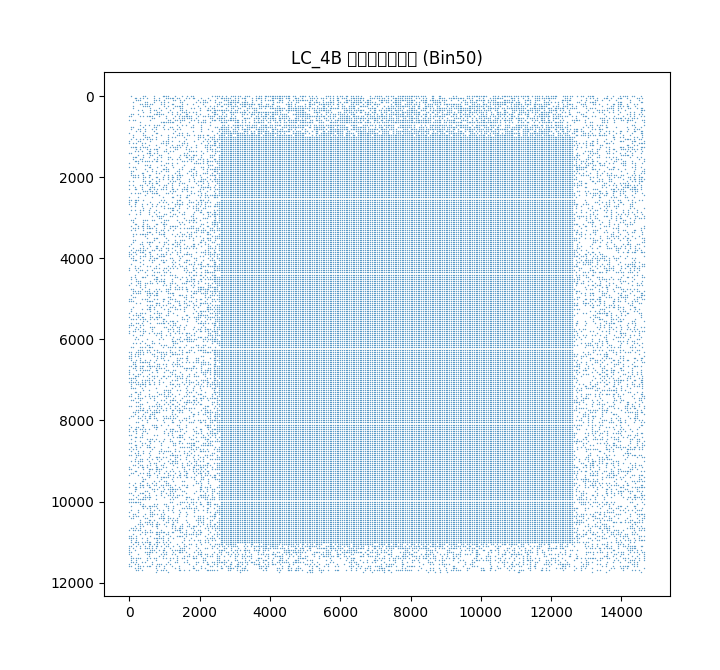

In [13]:
# Cell 4
# 空间散点图是空转数据 QC 的关键可视化。
# 原因：可以直观看到信号在芯片上的空间分布，判断是否存在边缘效应、局部异常区域或组织结构对应关系。

if hasattr(data, "position") and data.position is not None:
    pos = np.array(data.position)
    x, y = pos[:, 0], pos[:, 1]
elif hasattr(data, "cells") and hasattr(data.cells, "x") and hasattr(data.cells, "y"):
    x = np.array(data.cells.x)
    y = np.array(data.cells.y)
else:
    raise ValueError("未找到空间坐标字段，请检查 data.position 或 data.cells.x/y")

plt.figure(figsize=(6.5, 6))
plt.scatter(x, y, s=1, alpha=0.7)
plt.gca().invert_yaxis()
plt.title("LC_4B 原始空间散点图 (Bin50)")
plt.tight_layout()
plt.show()

[2026-03-15 15:15:36][Stereo][3304742][MainThread][123139629504320][st_pipeline][41][INFO]: start to run cal_qc...
[2026-03-15 15:15:37][Stereo][3304742][MainThread][123139629504320][st_pipeline][44][INFO]: cal_qc end, consume time 1.3309s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

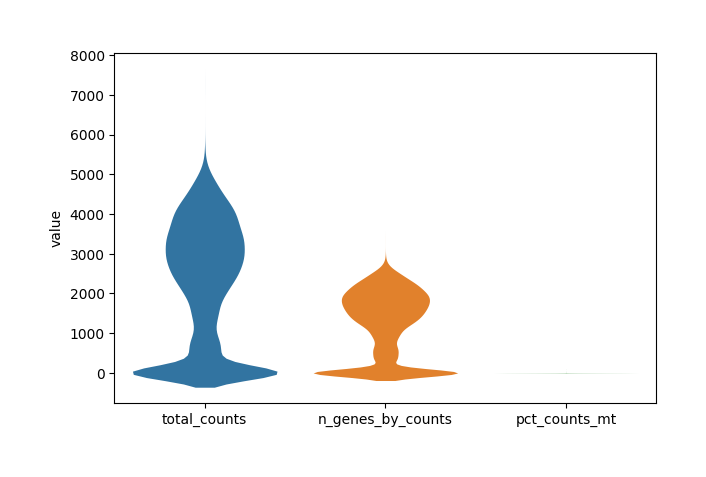

In [9]:
data.tl.cal_qc()
data.plt.violin()

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

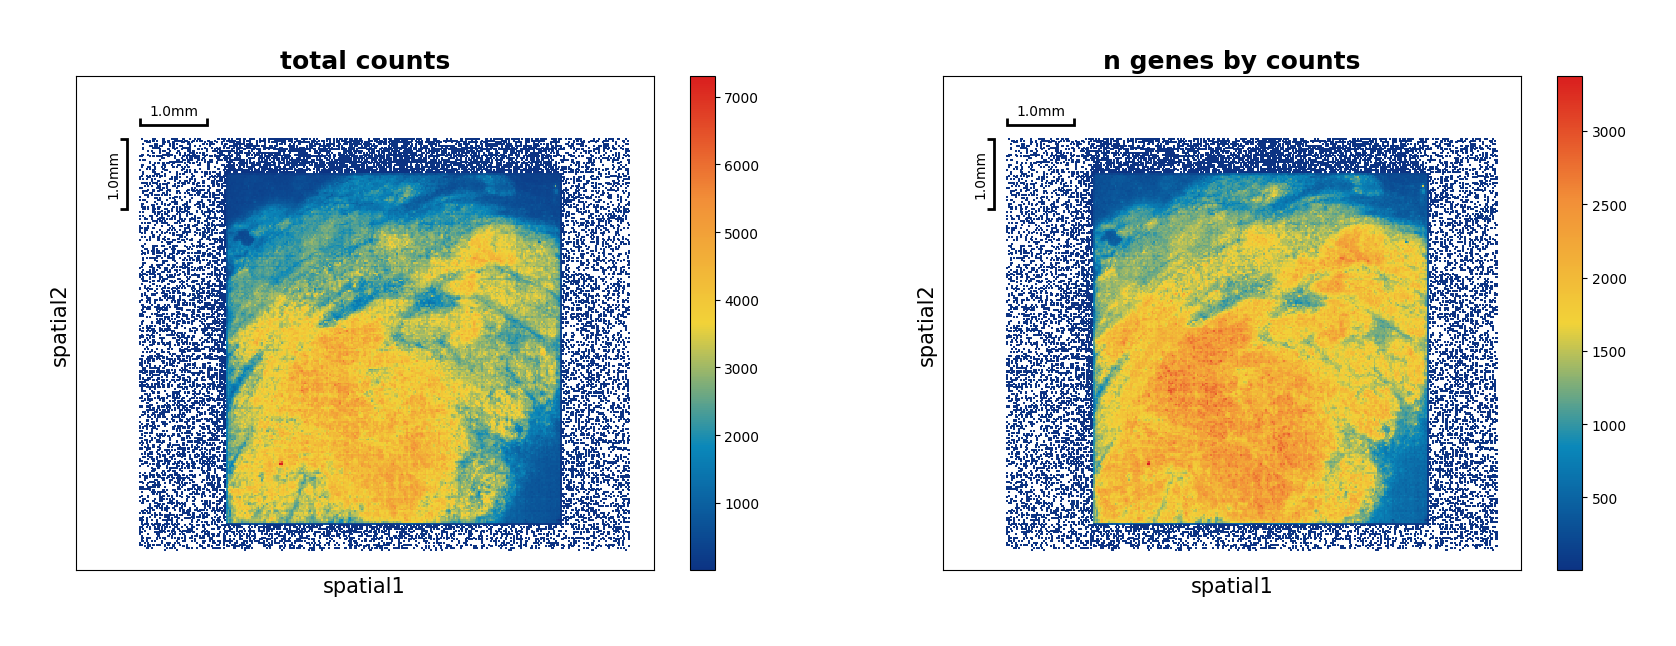

In [8]:
data.plt.spatial_scatter()

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

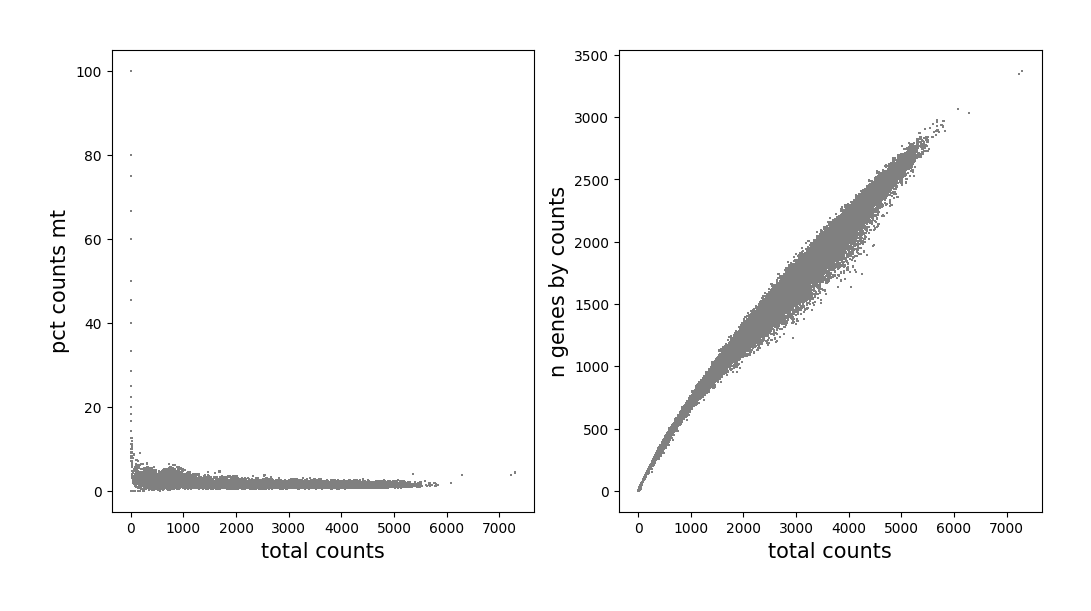

In [17]:
data.plt.genes_count()

In [10]:
data

StereoExpData object with n_cells X n_genes = 51658 X 49350
bin_type: bins
bin_size: 50
offset_x = 0
offset_y = 0
cells: ['cell_name', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt']
genes: ['gene_name', 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi']
cells_matrix = ['spatial']
Layers with keys: 
tl.result: []